In [1]:
# Data handling
import pandas as pd
import numpy as np

# Preprocessing & ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load CICIDS2017 dataset (your CSV file)
df = pd.read_csv("CICIDS2017.csv")

print("Shape of dataset:", df.shape)
print("Columns:", df.columns[:15])  # first 15 columns
df.head()


Shape of dataset: (2830743, 77)
Columns: Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s'],
      dtype='object')


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,1,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,1,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,1,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,3,2,0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Replace NaN / Inf if present
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Separate features and labels
X = df.drop("Label", axis=1, errors="ignore")   # features
y = df["Label"] if "Label" in df.columns else None  # target

# Encode labels: Normal = 0, Attack = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Scale numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Preprocessing done ")


Missing values: 0
Preprocessing done 


In [4]:
# Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1981520, 76)
Test shape: (849223, 76)


In [5]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training complete ")


Model training complete 


Accuracy: 0.9891971837785835

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    707787
           1       0.83      0.77      0.80       590
           2       1.00      0.99      1.00      4150
           3       0.74      0.53      0.62     12551
           4       1.00      1.00      1.00     75798
           5       1.00      1.00      1.00         3
           6       1.00      0.64      0.78        11
           7       0.99      1.00      1.00     47679
           8       0.99      0.97      0.98       654

    accuracy                           0.99    849223
   macro avg       0.95      0.88      0.91    849223
weighted avg       0.99      0.99      0.99    849223



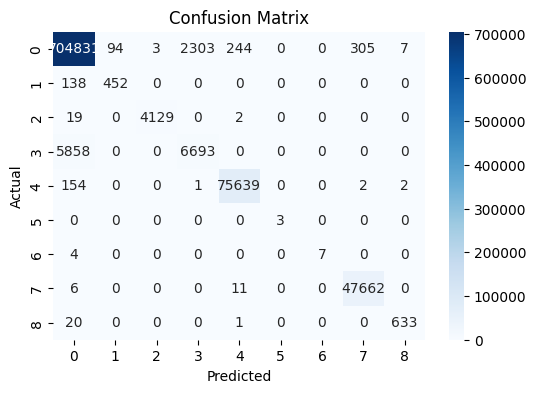

In [6]:
# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [8]:
import joblib

In [ ]:
# Save model and scaler
joblib.dump(rf_model, "ids_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")
print("✅ Model, Scaler, and Encoder saved!")


✅ Model, Scaler, and Encoder saved!


In [11]:
# Load model and preprocessing objects
loaded_model = joblib.load("ids_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

# Example: Take a few test samples
sample = X_test[:5]  # first 5 rows
true_labels = y_test[:5]

# Predict
pred = loaded_model.predict(sample)

# Decode labels back to original names
decoded_pred = loaded_encoder.inverse_transform(pred)
decoded_true = loaded_encoder.inverse_transform(true_labels)

print("Predictions:", decoded_pred)
print("True Labels:", decoded_true)


Predictions: ['BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN']
True Labels: ['BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN']


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build a simple ANN model
ann = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = ann.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Evaluate
loss, acc = ann.evaluate(X_test, y_test)
print("ANN Test Accuracy:", acc)


c:\Users\Muhammad\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
30962/30962 ━━━━━━━━━━━━━━━━━━━━ 149s 5ms/step - accuracy: 0.4096 - loss: -40085552.0000 - val_accuracy: 0.4067 - val_loss: -144828384.0000
Epoch 2/5
30962/30962 ━━━━━━━━━━━━━━━━━━━━ 146s 5ms/step - accuracy: 0.4105 - loss: -468711424.0000 - val_accuracy: 0.4101 - val_loss: -946982912.0000
Epoch 3/5
30962/30962 ━━━━━━━━━━━━━━━━━━━━ 147s 5ms/step - accuracy: 0.4110 - loss: -1822490624.0000 - val_accuracy: 0.4098 - val_loss: -2934420480.0000
Epoch 4/5
30962/30962 ━━━━━━━━━━━━━━━━━━━━ 132s 4ms/step - accuracy: 0.4106 - loss: -4622454272.0000 - val_accuracy: 0.4111 - val_loss: -6633879552.0000
Epoch 5/5
30962/30962 ━━━━━━━━━━━━━━━━━━━━ 248s 8ms/step - accuracy: 0.4108 - loss: -9388532736.0000 - val_accuracy: 0.4106 - val_loss: -12551021568.0000
26539/26539 ━━━━━━━━━━━━━━━━━━━━ 97s 4ms/step - accuracy: 0.4106 - loss: -12551009280.0000
ANN Test Accuracy: 0.4106471538543701
